In [7]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sqlalchemy import create_engine
from dotenv import load_dotenv

sns.set(style="whitegrid")
%matplotlib inline

load_dotenv()
engine = create_engine(os.getenv("DATABASE_URL"))

In [9]:
dim_company = pd.read_sql("SELECT * FROM dim_company", engine)
pl = pd.read_sql("SELECT * FROM fact_profit_loss", engine)
bs = pd.read_sql("SELECT * FROM fact_balance_sheet", engine)
cf = pd.read_sql("SELECT * FROM fact_cash_flow", engine)
fa = pd.read_sql("SELECT * FROM fact_analysis", engine)

In [10]:
pl_y = pl[~pl["year_label"].str.contains("TTM", case=False, na=False)].copy()
bs_y = bs[~bs["year_label"].str.contains("TTM", case=False, na=False)].copy()
cf_y = cf[~cf["year_label"].str.contains("TTM", case=False, na=False)].copy()

In [12]:
import pandas as pd
import numpy as np

# -----------------------------
# Convert columns to numeric
# -----------------------------
pl_y["sales"] = pd.to_numeric(pl_y["sales"], errors="coerce")
pl_y["net_profit"] = pd.to_numeric(pl_y["net_profit"], errors="coerce")
pl_y["opm_pct"] = pd.to_numeric(pl_y["opm_pct"], errors="coerce")

dim_company["roe_pct"] = pd.to_numeric(
    dim_company["roe_pct"],
    errors="coerce"
)

# -----------------------------
# Company master table
# -----------------------------
companies = dim_company[
    ["symbol", "company_name", "sector", "roe_pct"]
].copy()

# -----------------------------
# Latest non-TTM year per symbol
# -----------------------------
latest_year = (
    pl_y.groupby("symbol")["year_label"]
    .max()
    .reset_index()
    .rename(columns={"year_label": "latest_year"})
)

# -----------------------------
# Profitability metrics
# -----------------------------
pl_y["net_margin_pct"] = (
    pl_y["net_profit"] / pl_y["sales"]
) * 100

# -----------------------------
# Profitability features
# -----------------------------
profit_feats = (
    pl_y.groupby("symbol")
    .agg(
        avg_opm=("opm_pct", "mean"),
        avg_net_margin=("net_margin_pct", "mean")
    )
    .reset_index()
)

# -----------------------------
# Add ROE
# -----------------------------
profit_feats = profit_feats.merge(
    dim_company[["symbol", "roe_pct"]],
    on="symbol",
    how="left"
)

# -----------------------------
# View result
# -----------------------------
print(profit_feats.head())
print("\nShape:", profit_feats.shape)

       symbol  avg_opm  avg_net_margin  roe_pct
0         ABB   17.250       13.018494    34.90
1  ADANIENSOL   52.300       10.952483     8.59
2    ADANIENT    8.750        2.576703    13.64
3  ADANIGREEN   68.875       -0.362998    14.70
4  ADANIPORTS   60.500       36.075361    18.10

Shape: (100, 4)


In [13]:
growth_feats = fa[fa["period_label"]=="3Y"][
    ["symbol", "compounded_sales_growth_pct", "compounded_profit_growth_pct"]
].rename(
    columns={
        "compounded_sales_growth_pct": "sales_cagr_3y",
        "compounded_profit_growth_pct": "profit_cagr_3y",
    }
)

In [14]:
bs_latest = (
    bs_y.sort_values(["symbol", "year_label"])
    .drop_duplicates(subset="symbol", keep="last")
)

lev_feats = bs_latest[["symbol", "debt_to_equity"]].rename(
    columns={"debt_to_equity": "de_ratio_latest"}
)

In [19]:
import pandas as pd
import numpy as np

# --------------------------------
# Convert numeric columns
# --------------------------------
for col in ["free_cash_flow"]:
    if col in cf_y.columns:
        cf_y[col] = pd.to_numeric(cf_y[col], errors="coerce")

# --------------------------------
# Cash Conversion Ratio
# --------------------------------
if "cash_conversion_ratio" in cf_y.columns:
    
    cf_y["ccr"] = pd.to_numeric(
        cf_y["cash_conversion_ratio"],
        errors="coerce"
    )

elif (
    "cash_from_operating_activity" in cf_y.columns
    and "net_profit" in cf_y.columns
):
    
    cf_y["cash_from_operating_activity"] = pd.to_numeric(
        cf_y["cash_from_operating_activity"],
        errors="coerce"
    )

    cf_y["net_profit"] = pd.to_numeric(
        cf_y["net_profit"],
        errors="coerce"
    )

    cf_y["ccr"] = (
        cf_y["cash_from_operating_activity"]
        / cf_y["net_profit"].replace(0, np.nan)
    )

else:
    
    print("cash_conversion_ratio not available")
    cf_y["ccr"] = np.nan

# --------------------------------
# Cash Flow Features
# --------------------------------
cf_feats = (
    cf_y.groupby("symbol")
    .agg(
        avg_ccr=("ccr", "mean"),
        fcf_positive_years=(
            "free_cash_flow",
            lambda x: (x > 0).sum()
        ),
        fcf_total_years=(
            "free_cash_flow",
            "count"
        )
    )
    .reset_index()
)

# --------------------------------
# Percentage of positive FCF years
# --------------------------------
cf_feats["fcf_positive_pct"] = (
    cf_feats["fcf_positive_years"]
    / cf_feats["fcf_total_years"].clip(lower=1)
) * 100

# --------------------------------
# View Result
# --------------------------------
print(cf_feats.head())
print("\nShape:", cf_feats.shape)

cash_conversion_ratio not available
       symbol  avg_ccr  fcf_positive_years  fcf_total_years  fcf_positive_pct
0         ABB      NaN                  15               23         65.217391
1  ADANIENSOL      NaN                   4               11         36.363636
2    ADANIENT      NaN                   5               12         41.666667
3  ADANIGREEN      NaN                   1                8         12.500000
4  ADANIPORTS      NaN                   7               12         58.333333

Shape: (100, 5)


In [22]:
import pandas as pd
import numpy as np

# ----------------------------------
# Convert dividend column to numeric
# ----------------------------------
pl_y["dividend_payout_pct"] = pd.to_numeric(
    pl_y["dividend_payout_pct"],
    errors="coerce"
)

# ----------------------------------
# Keep last N years per company
# ----------------------------------
def last_n_years(df, n=5):
    out = []

    for sym, g in df.groupby("symbol"):
        g = g.sort_values("year_label")
        out.append(g.tail(n))

    return pd.concat(out, ignore_index=True)

pl_5y = last_n_years(pl_y, n=5)

# ----------------------------------
# Dividend features
# ----------------------------------
div_feats = (
    pl_5y.groupby("symbol")
    .agg(
        avg_payout_5y=(
            "dividend_payout_pct",
            "mean"
        ),
        years_with_dividend=(
            "dividend_payout_pct",
            lambda x: (x.fillna(0) > 0).sum()
        ),
        total_years=(
            "dividend_payout_pct",
            "count"
        )
    )
    .reset_index()
)

# ----------------------------------
# % years with dividend
# ----------------------------------
div_feats["div_years_pct"] = (
    div_feats["years_with_dividend"]
    / div_feats["total_years"].clip(lower=1)
) * 100

# ----------------------------------
# View result
# ----------------------------------
print(div_feats.head())
print("\nShape:", div_feats.shape)

       symbol  avg_payout_5y  years_with_dividend  total_years  div_years_pct
0         ABB           78.8                    5            5          100.0
1  ADANIENSOL            0.0                    0            5            0.0
2    ADANIENT            9.4                    5            5          100.0
3  ADANIGREEN            0.0                    0            5            0.0
4  ADANIPORTS           18.8                    5            5          100.0

Shape: (100, 5)


In [23]:
from numpy.polynomial.polynomial import polyfit

trend_rows = []
for sym, g in pl_y.groupby("symbol"):
    g2 = g.sort_values("year_label").tail(5)
    if len(g2) < 2:
        continue
    # convert year_label to numeric index 0..n-1
    x = np.arange(len(g2))
    y_sales = g2["sales"].values.astype(float)
    # simple linear slope
    b0, b1 = polyfit(x, y_sales, 1)
    trend_rows.append({"symbol": sym, "sales_trend_slope": b1})

trend_feats = pd.DataFrame(trend_rows)

In [24]:
features = companies.merge(profit_feats, on="symbol", how="left") \
    .merge(growth_feats, on="symbol", how="left") \
    .merge(lev_feats, on="symbol", how="left") \
    .merge(cf_feats, on="symbol", how="left") \
    .merge(div_feats, on="symbol", how="left") \
    .merge(trend_feats, on="symbol", how="left")

In [25]:
def min_max(series, invert=False):
    s = series.astype(float)
    if invert:
        s = -s  # lower original becomes higher score
    mn, mx = s.min(), s.max()
    if pd.isna(mn) or pd.isna(mx) or mx == mn:
        return pd.Series([0.5] * len(s), index=s.index)  # neutral if no spread
    return (s - mn) / (mx - mn)

In [30]:
# Create working copy
dim = features.copy()

# Add roe_pct if missing
if "roe_pct" not in dim.columns and "symbol" in dim.columns:
    dim = dim.merge(
        dim_company[["symbol", "roe_pct"]],
        on="symbol",
        how="left"
    )

# Profitability
dim["profitability_raw"] = (
    dim[["avg_opm", "avg_net_margin", "roe_pct"]]
    .apply(pd.to_numeric, errors="coerce")
    .mean(axis=1)
)

# Growth
dim["growth_raw"] = pd.to_numeric(
    dim["sales_cagr_3y"],
    errors="coerce"
)

# Leverage
dim["leverage_raw"] = pd.to_numeric(
    dim["de_ratio_latest"],
    errors="coerce"
)

# Cash Flow
dim["cashflow_raw"] = (
    dim[["avg_ccr", "fcf_positive_pct"]]
    .apply(pd.to_numeric, errors="coerce")
    .mean(axis=1)
)

# Dividend
dim["dividend_raw"] = (
    dim[["avg_payout_5y", "div_years_pct"]]
    .apply(pd.to_numeric, errors="coerce")
    .mean(axis=1)
)

# Trend
dim["trend_raw"] = pd.to_numeric(
    dim["sales_trend_slope"],
    errors="coerce"
)

print(dim.head())

       symbol                             company_name          sector  \
0         ABB                         Abbott India Ltd   Capital Goods   
1  ADANIENSOL               Adani Energy Solutions Ltd          Energy   
2    ADANIENT                    Adani Enterprises Ltd  Infrastructure   
3  ADANIGREEN                   Adani Green Energy Ltd          Energy   
4  ADANIPORTS  Adani Ports & Special Economic Zone Ltd  Infrastructure   

   roe_pct_x  avg_opm  avg_net_margin  roe_pct_y  sales_cagr_3y  \
0      34.90   17.250       13.018494      34.90            NaN   
1       8.59   52.300       10.952483       8.59            NaN   
2      13.64    8.750        2.576703      13.64            NaN   
3      14.70   68.875       -0.362998      14.70            NaN   
4      18.10   60.500       36.075361      18.10            NaN   

   profit_cagr_3y  de_ratio_latest  ...  total_years  div_years_pct  \
0             NaN         0.017041  ...          5.0          100.0   
1         

In [31]:
dim["profitability_norm"] = min_max(dim["profitability_raw"])
dim["growth_norm"]        = min_max(dim["growth_raw"])
dim["leverage_norm"]      = min_max(dim["leverage_raw"], invert=True)
dim["cashflow_norm"]      = min_max(dim["cashflow_raw"])
dim["dividend_norm"]      = min_max(dim["dividend_raw"])
dim["trend_norm"]         = min_max(dim["trend_raw"])

weights = {
    "profitability_norm": 0.25,
    "growth_norm":        0.20,
    "leverage_norm":      0.20,
    "cashflow_norm":      0.15,
    "dividend_norm":      0.10,
    "trend_norm":         0.10,
}

dim["health_score"] = 0
for col, w in weights.items():
    dim["health_score"] += dim[col] * w * 100  # 0–100 scale

In [32]:
def label_from_score(s):
    if s >= 85: return "EXCELLENT"
    if s >= 70: return "GOOD"
    if s >= 50: return "AVERAGE"
    if s >= 35: return "WEAK"
    return "POOR"

dim["health_label"] = dim["health_score"].apply(label_from_score)

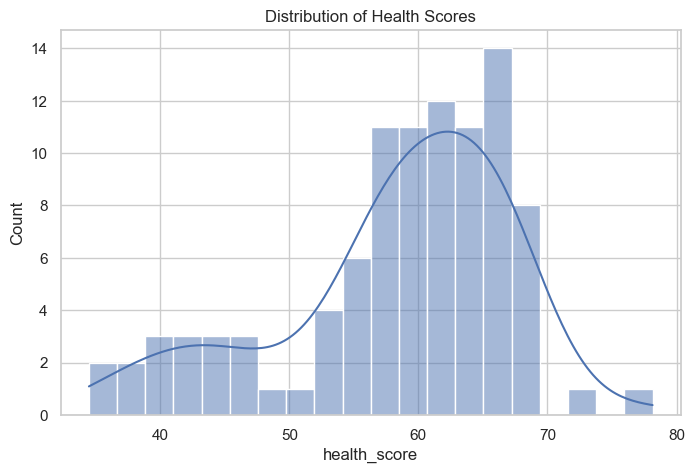

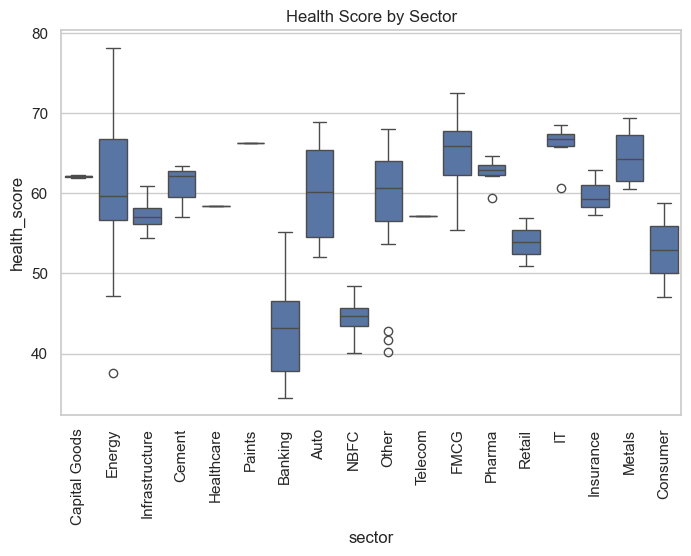

In [33]:
plt.figure(figsize=(8,5))
sns.histplot(dim["health_score"], bins=20, kde=True)
plt.title("Distribution of Health Scores")
plt.show()

plt.figure(figsize=(8,5))
sns.boxplot(data=dim, x="sector", y="health_score")
plt.xticks(rotation=90)
plt.title("Health Score by Sector")
plt.show()

In [34]:
check_syms = ["TCS", "HDFCBANK", "WIPRO", "ADANIPOWER", "APOLLOHOSP"]
dim[dim["symbol"].isin(check_syms)][
    ["symbol","company_name","sector",
     "health_score","health_label",
     "profitability_raw","growth_raw","leverage_raw",
     "cashflow_raw","dividend_raw","trend_raw"]
]

,symbol,company_name,sector,health_score,health_label,profitability_raw,growth_raw,leverage_raw,cashflow_raw,dividend_raw,trend_raw
5,ADANIPOWER,Adani Power Ltd,Energy,56.209730,AVERAGE,28.306708,NaN,0.673857,83.333333,0.0,6031.8
7,APOLLOHOSP,Apollo Hospitals Chain of Indian private hospi...,Healthcare,58.430742,AVERAGE,10.323219,NaN,0.982669,66.666667,61.5,2167.6
38,HDFCBANK,HDFC Bank Ltd,Banking,55.199693,AVERAGE,2907.938158,3.0,6.808787,50.000000,58.5,36512.2
86,TCS,Tata Consultancy Services Ltd,IT,68.497721,AVERAGE,16.366285,3.0,0.089128,100.000000,82.7,22916.9
98,WIPRO,WIPRO,IT,60.696302,AVERAGE,18.216463,3.0,0.236949,75.000000,54.8,8579.7


In [35]:
weights_alt = weights.copy()
weights_alt["leverage_norm"] = 0.30
weights_alt["profitability_norm"] = 0.15

dim["health_score_alt"] = 0
for col, w in weights_alt.items():
    dim["health_score_alt"] += dim[col] * w * 100

dim["score_delta"] = dim["health_score_alt"] - dim["health_score"]

dim.sort_values("score_delta", ascending=False)[
    ["symbol","company_name","health_score","health_score_alt","score_delta"]
].head(20)

,symbol,company_name,health_score,health_score_alt,score_delta
43,ICICIBANK,ICICI Bank Ltd,35.865317,41.529914,5.664598
76,SBILIFE,SBI Life Insurance Company Ltd,57.287663,61.681837,4.394174
63,MARUTI,Maruti Suzuki India Ltd,65.516744,69.906288,4.389544
19,BOSCHLTD,Bosch Ltd,66.499678,70.887385,4.387708
99,ZOMATO,ZOMATO,47.097035,51.483955,4.386920
58,LICI,Life Insurance Corporation of India,68.019073,72.403771,4.384698
27,DIVISLAB,Divis Laboratories Ltd,62.697907,67.080610,4.382704
100,ZYDUSLIFE,ZYDUSLIFE,59.468851,63.849723,4.380871
6,AMBUJACEM,Ambuja Cements Ltd,62.163165,66.542948,4.379783
80,SIEMENS,Siemens Ltd,62.319434,66.697201,4.377766


In [37]:
health_scores = dim[
    ["symbol","company_name","sector",
     "health_score","health_label",
     "profitability_norm","growth_norm","leverage_norm",
     "cashflow_norm","dividend_norm","trend_norm"]
]

out_path = "../data/clean/fact_ml_scores_notebook.csv"
health_scores.to_csv(out_path, index=False)
out_path

'../data/clean/fact_ml_scores_notebook.csv'